In [3]:
!pip install matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\Admin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the CSV
df = pd.read_csv("nairobi_weather.csv")

# Convert timestamp to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nLast 5 rows:")
print(df.tail())
print("\nData types:")
print(df.dtypes)
print("\nBasic statistics:")
print(df.describe())

Shape: (168, 5)

First 5 rows:
            timestamp  temperature_c  humidity_percent  rain_mm  \
0 2025-01-01 00:00:00           15.9                93      0.0   
1 2025-01-01 01:00:00           15.8                93      0.0   
2 2025-01-01 02:00:00           15.4                93      0.0   
3 2025-01-01 03:00:00           14.8                93      0.0   
4 2025-01-01 04:00:00           15.1                88      0.0   

   wind_speed_kmh  
0             5.3  
1             6.0  
2             5.4  
3             3.8  
4             3.7  

Last 5 rows:
              timestamp  temperature_c  humidity_percent  rain_mm  \
163 2025-01-07 19:00:00           18.5                61      0.0   
164 2025-01-07 20:00:00           17.6                67      0.0   
165 2025-01-07 21:00:00           17.0                72      0.0   
166 2025-01-07 22:00:00           16.5                75      0.0   
167 2025-01-07 23:00:00           16.1                78      0.0   

     wind_speed_k

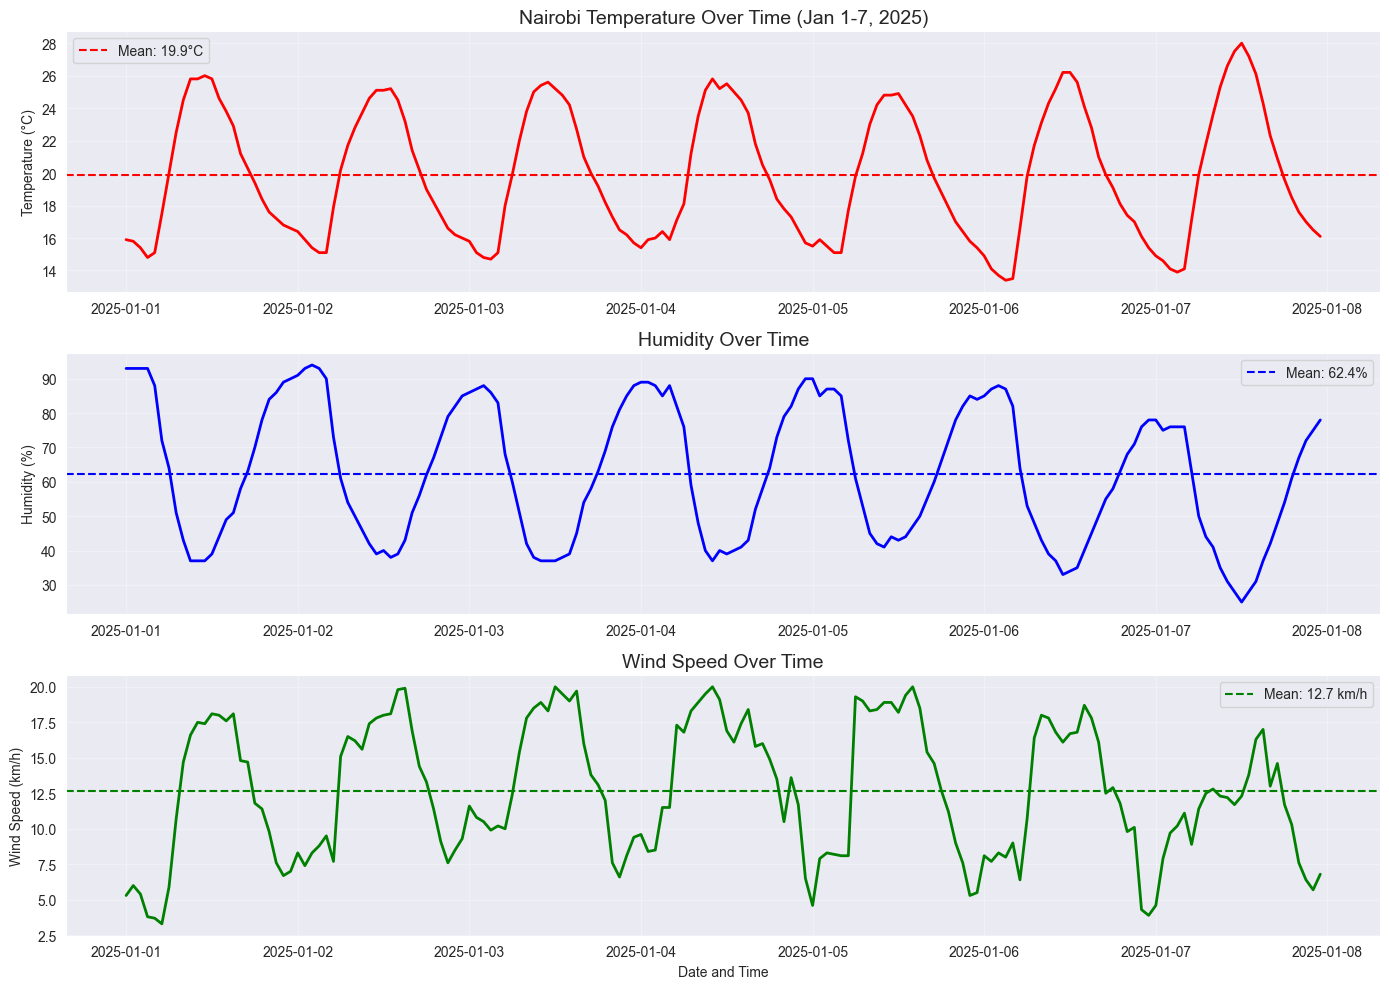

In [6]:
# Set a nice style for our charts
sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Create a figure with 3 subplots
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Plot 1: Temperature over time
axes[0].plot(df['timestamp'], df['temperature_c'], color='red', linewidth=2)
axes[0].set_title('Nairobi Temperature Over Time (Jan 1-7, 2025)', fontsize=14)
axes[0].set_ylabel('Temperature (°C)')
axes[0].axhline(y=df['temperature_c'].mean(), color='red', linestyle='--', label=f'Mean: {df["temperature_c"].mean():.1f}°C')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Humidity over time
axes[1].plot(df['timestamp'], df['humidity_percent'], color='blue', linewidth=2)
axes[1].set_title('Humidity Over Time', fontsize=14)
axes[1].set_ylabel('Humidity (%)')
axes[1].axhline(y=df['humidity_percent'].mean(), color='blue', linestyle='--', label=f'Mean: {df["humidity_percent"].mean():.1f}%')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: Wind speed over time
axes[2].plot(df['timestamp'], df['wind_speed_kmh'], color='green', linewidth=2)
axes[2].set_title('Wind Speed Over Time', fontsize=14)
axes[2].set_xlabel('Date and Time')
axes[2].set_ylabel('Wind Speed (km/h)')
axes[2].axhline(y=df['wind_speed_kmh'].mean(), color='green', linestyle='--', label=f'Mean: {df["wind_speed_kmh"].mean():.1f} km/h')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
# Find temperature anomalies (unusually hot or cold)
mean_temp = df['temperature_c'].mean()
std_temp = df['temperature_c'].std()

# Define anomaly as temperature more than 2 standard deviations from mean
hot_anomalies = df[df['temperature_c'] > mean_temp + 2*std_temp]
cold_anomalies = df[df['temperature_c'] < mean_temp - 2*std_temp]

print(f"Mean temperature: {mean_temp:.1f}°C")
print(f"Standard deviation: {std_temp:.1f}°C")
print(f"\n🔥 Hot anomalies (above {mean_temp + 2*std_temp:.1f}°C):")
print(hot_anomalies[['timestamp', 'temperature_c']])

print(f"\n❄️ Cold anomalies (below {mean_temp - 2*std_temp:.1f}°C):")
print(cold_anomalies[['timestamp', 'temperature_c']])

# Also check for rain (any rain is unusual in this dry week)
rain_days = df[df['rain_mm'] > 0]
print(f"\n🌧️ Rain events ({len(rain_days)} hours with rain):")
print(rain_days[['timestamp', 'rain_mm', 'temperature_c']])

Mean temperature: 19.9°C
Standard deviation: 4.0°C

🔥 Hot anomalies (above 27.9°C):
              timestamp  temperature_c
156 2025-01-07 12:00:00           28.0

❄️ Cold anomalies (below 11.9°C):
Empty DataFrame
Columns: [timestamp, temperature_c]
Index: []

🌧️ Rain events (21 hours with rain):
              timestamp  rain_mm  temperature_c
10  2025-01-01 10:00:00      0.1           25.8
11  2025-01-01 11:00:00      0.2           26.0
12  2025-01-01 12:00:00      0.1           25.8
13  2025-01-01 13:00:00      0.1           24.6
14  2025-01-01 14:00:00      0.2           23.8
21  2025-01-01 21:00:00      0.1           17.2
22  2025-01-01 22:00:00      0.1           16.8
23  2025-01-01 23:00:00      0.1           16.6
24  2025-01-02 00:00:00      0.2           16.4
33  2025-01-02 09:00:00      0.1           23.7
36  2025-01-02 12:00:00      0.1           25.1
75  2025-01-04 03:00:00      0.1           16.4
76  2025-01-04 04:00:00      0.2           15.9
77  2025-01-04 05:00:00      0.

In [8]:
# Extract time-based features
df['hour'] = df['timestamp'].dt.hour
df['day'] = df['timestamp'].dt.day
df['day_of_week'] = df['timestamp'].dt.day_name()

# Create temperature categories
df['temp_category'] = pd.cut(df['temperature_c'], 
                              bins=[0, 15, 20, 25, 100],
                              labels=['Cold (<15°C)', 'Cool (15-20°C)', 'Warm (20-25°C)', 'Hot (>25°C)'])

# Temperature change from previous hour
df['temp_change'] = df['temperature_c'].diff()

# Rolling averages (smoothing)
df['temp_3hr_avg'] = df['temperature_c'].rolling(window=3).mean()

print("New features added:")
print(df[['timestamp', 'hour', 'day', 'day_of_week', 'temp_category', 'temp_change', 'temp_3hr_avg']].head(10))

New features added:
            timestamp  hour  day day_of_week   temp_category  temp_change  \
0 2025-01-01 00:00:00     0    1   Wednesday  Cool (15-20°C)          NaN   
1 2025-01-01 01:00:00     1    1   Wednesday  Cool (15-20°C)         -0.1   
2 2025-01-01 02:00:00     2    1   Wednesday  Cool (15-20°C)         -0.4   
3 2025-01-01 03:00:00     3    1   Wednesday    Cold (<15°C)         -0.6   
4 2025-01-01 04:00:00     4    1   Wednesday  Cool (15-20°C)          0.3   
5 2025-01-01 05:00:00     5    1   Wednesday  Cool (15-20°C)          2.4   
6 2025-01-01 06:00:00     6    1   Wednesday  Cool (15-20°C)          2.5   
7 2025-01-01 07:00:00     7    1   Wednesday  Warm (20-25°C)          2.5   
8 2025-01-01 08:00:00     8    1   Wednesday  Warm (20-25°C)          2.0   
9 2025-01-01 09:00:00     9    1   Wednesday     Hot (>25°C)          1.3   

   temp_3hr_avg  
0           NaN  
1           NaN  
2     15.700000  
3     15.333333  
4     15.100000  
5     15.800000  
6     

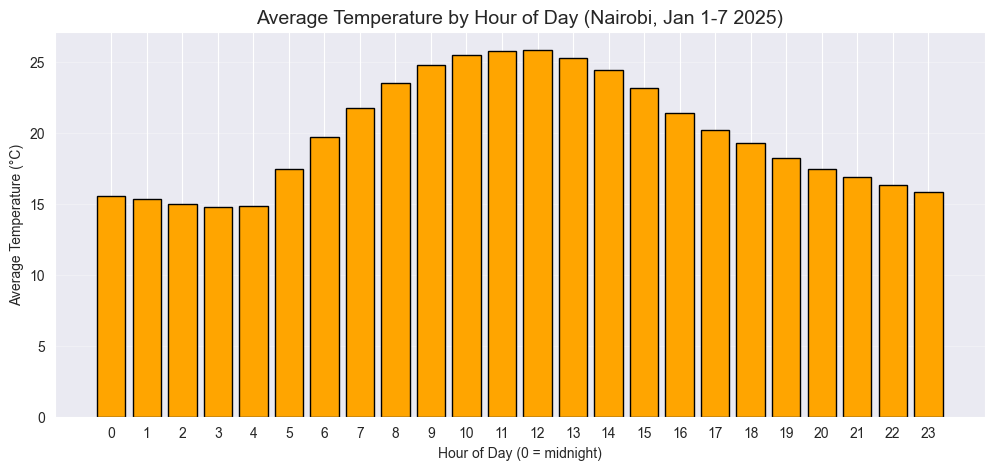


Coolest hour: 3 (14.8°C)
Warmest hour: 12 (25.8°C)


In [ ]:
# Average temperature by hour of day
hourly_avg = df.groupby('hour')['temperature_c'].mean()

plt.figure(figsize=(12, 5))
plt.bar(hourly_avg.index, hourly_avg.values, color='grey', edgecolor='black')
plt.title('Average Temperature by Hour of Day (Nairobi, Jan 1-7 2025)', fontsize=14)
plt.xlabel('Hour of Day (0 = midnight)')
plt.ylabel('Average Temperature (°C)')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3, axis='y')
plt.show()

print("\nCoolest hour:", hourly_avg.idxmin(), f"({hourly_avg.min():.1f}°C)")
print("Warmest hour:", hourly_avg.idxmax(), f"({hourly_avg.max():.1f}°C)")

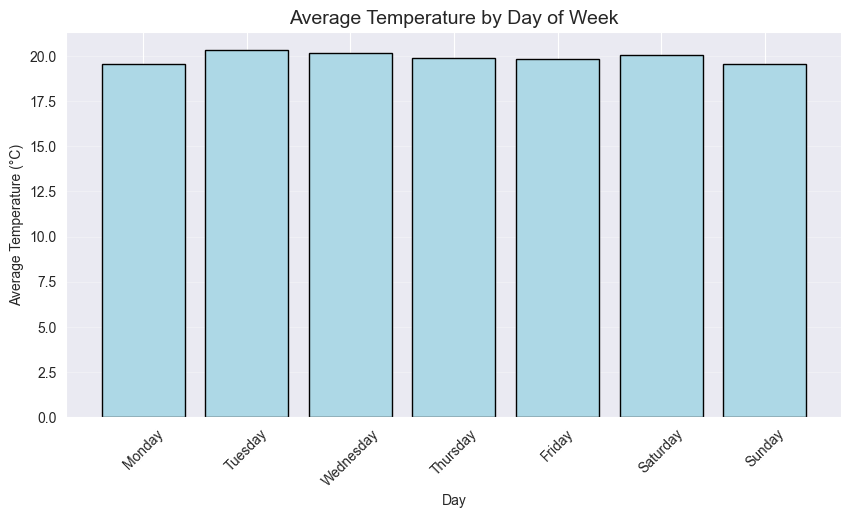

In [10]:
# Average temperature by day of week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_avg = df.groupby('day_of_week')['temperature_c'].mean().reindex(day_order)

plt.figure(figsize=(10, 5))
plt.bar(daily_avg.index, daily_avg.values, color='lightblue', edgecolor='black')
plt.title('Average Temperature by Day of Week', fontsize=14)
plt.xlabel('Day')
plt.ylabel('Average Temperature (°C)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')
plt.show()

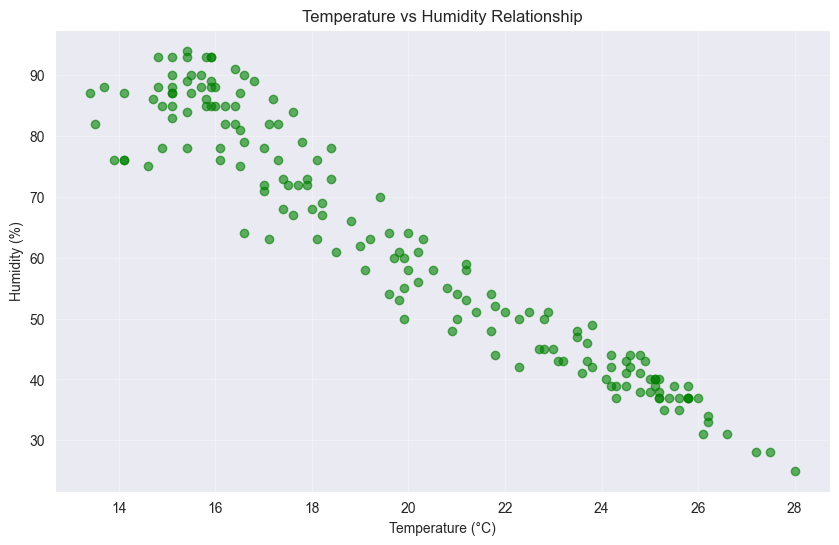

Correlation between temperature and humidity: -0.96


In [12]:
# Scatter plot: Temperature vs Humidity
plt.figure(figsize=(10, 6))
plt.scatter(df['temperature_c'], df['humidity_percent'], alpha=0.6, c='green')
plt.title('Temperature vs Humidity Relationship')
plt.xlabel('Temperature (°C)')
plt.ylabel('Humidity (%)')
plt.grid(True, alpha=0.3)
plt.show()

# Correlation
correlation = df['temperature_c'].corr(df['humidity_percent'])
print(f"Correlation between temperature and humidity: {correlation:.2f}")
# (Negative correlation means: hotter = less humid)

In [1]:
# Save the enhanced dataset with new features
df.to_csv("nairobi_weather_enhanced.csv", index=False)
print("Saved enhanced dataset with new features")

NameError: name 'df' is not defined

In [ ]:
# Create requirements.txt
with open('requirements.txt', 'w') as f:
    f.write('pandas==2.0.3\n')
    f.write('numpy==1.24.3\n')
    f.write('matplotlib==3.7.1\n')
    f.write('seaborn==0.12.2\n')
    f.write('jupyter==1.0.0\n')
    
print("requirements.txt created")